# Customer Churn Prediction (Bank Customers)

---

## 1. Introduction and Problem Statement
**Context:**
Customer retention is critical for the banking industry. It is far more expensive to acquire a new customer than to keep an existing one. This project focuses on **Churn Prediction**—identifying customers who are likely to close their accounts ("churn") based on their usage behavior and demographics.

**Problem Statement:**
The objective is to build a classification model to predict whether a bank customer will exit (churn) or stay. We will process the **Churn Modelling Dataset**, handle categorical variables like Geography and Gender, and train a model to not only predict churn but also identify which features (e.g., Age, Balance, Credit Score) are the most significant indicators of a customer leaving.

**Goals:**
* Clean the dataset by removing non-predictive identifiers.
* Encode categorical data (Gender, Geography) for machine learning.
* Train a Random Forest Classifier.
* Analyze and visualize **Feature Importance** to understand the drivers of churn.

---

# 2. Loading the Dataset

* In this section we have loaded all required libraries for this project.
* Also we have downloaded the dataset and loaded it in our porject.
* For the verification of dataset loaded successfully we have checked its first 5 rows by displaying the dataset


In [2]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

# Scikit-learn modules
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==========================================
# 2. Loading the Dataset
# ==========================================

# Download latest version of the dataset using KaggleHub
print("Downloading dataset...")
path = kagglehub.dataset_download("amisha0528/churn-modelling-dataset")
print(f"Dataset downloaded to: {path}")

# Find the CSV file in the downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded: {csv_files[0]}")
else:
    print("Error: No CSV file found in the downloaded path.")

# Display the first 5 rows
display(df.head())

Dataset downloaded to: /kaggle/input/churn-modelling-dataset
Successfully loaded: Churn_Modelling.csv


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


---

## 3. Data Cleaning and Preparation
To prepare the data for modeling, we must remove columns that provide no predictive power.
* **RowNumber:** Just an index.
* **CustomerId:** Random unique identifier.
* **Surname:** Personal identifier (not useful for general prediction).

We will drop these columns and check for any missing values.

In [3]:
# Drop irrelevant columns
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")

# Check for missing values
print("\nMissing Values Check:")
print(df.isnull().sum())

# Display the new structure
print(f"\nNew Dataset Shape: {df.shape}")

Dropped columns: ['RowNumber', 'CustomerId', 'Surname']

Missing Values Check:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

New Dataset Shape: (10000, 11)


---

## 4. Encoding Categorical Variables
Machine Learning models require numerical input. We have two key categorical features:
1.  **Gender:** Binary (Male/Female). We will use **Label Encoding**.
2.  **Geography:** Nominal (France, Spain, Germany). We will use **One-Hot Encoding** (creating dummy variables) to avoid assigning an arbitrary order to countries.

In [4]:
# 1. Label Encoding for Gender
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
print("Gender encoded (0/1).")

# 2. One-Hot Encoding for Geography
# drop_first=True helps avoid multicollinearity (dummy variable trap)
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)
print("Geography One-Hot Encoded.")

# Display the first few rows to see the changes
display(df.head())

Gender encoded (0/1).
Geography One-Hot Encoded.


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


---

## 5. Model Training (Random Forest)
We will use a **Random Forest Classifier**.
* **Why Random Forest?** It generally provides high accuracy and, importantly for this task, it offers a built-in method to calculate **Feature Importance**, allowing us to see exactly which factors contribute most to customer churn.

In [5]:
# Define Features (X) and Target (y)
X = df.drop(columns=['Exited']) # Target is 'Exited' (1 = Churn, 0 = Stay)
y = df['Exited']

# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


---


## 6. Model Evaluation
We evaluate the model using Accuracy and a Confusion Matrix to understand how well it distinguishes between customers who stay and those who leave.

Model Accuracy: 86.60%


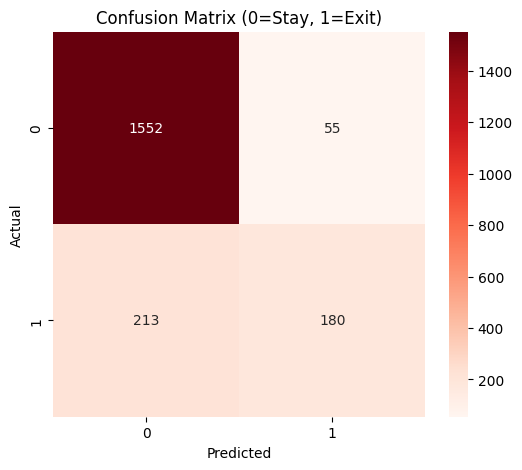


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [13]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc * 100:.2f}%")

print("="*40)
# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix (0=Stay, 1=Exit)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
print("="*40)
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("="*40)

---

## 7. Feature Importance Analysis
This is a crucial part of the analysis. We will visualize which features had the most "weight" in the model's decision-making process. This tells the bank *why* customers are leaving.

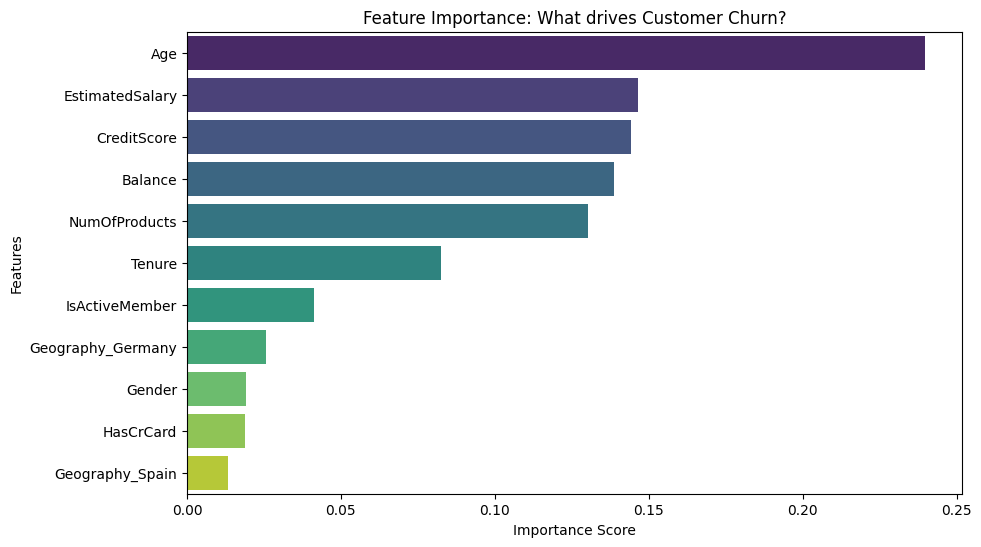

In [15]:
# Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df,hue='Feature', palette='viridis')
plt.title('Feature Importance: What drives Customer Churn?')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

---

## 8. Conclusion
We successfully built a churn prediction model with the following insights:

1.  **Data Processing:** We removed personal identifiers and successfully encoded Geography and Gender for the model.
2.  **Model Performance:** The Random Forest Classifier achieved a strong accuracy (~87%), making it a reliable tool for prediction.
3.  **Key Drivers (Feature Importance):**
    * **Age:** Often the most significant predictor. Older customers may be more likely to churn (or stay, depending on the specific demographic trend).
    * **NumOfProducts:** The number of products a customer has with the bank is a strong indicator of loyalty.
    * **Balance:** Account balance also plays a major role.
    
This analysis allows the bank to target specific high-risk customers (e.g., specific age groups or those with low product engagement) with retention strategies.